# Project Checkpoint 2 — Research Question Formation

**Dataset:** Yahoo Answers Topic Classification Dataset  
**Course:** Data Mining

---

> **Notebook structure:**
> 1. Project Scope Recap  
> 2. Setup and Data Loading  
> 3. Additional EDA — *run first to discover interesting questions*  
> 4. Research Question Definition *(derived from EDA findings)*  
> 5. Motivation and Feasibility  
> 6. Methodological Planning and Initial Method Runs  
> 7. Sanity Tests  
> 8. Summary and Next Steps  
> 9. Resources

---
# Section 1 — Project Scope Recap

## 1.1 Dataset Summary

The selected dataset is the **Yahoo Answers Topic Classification Dataset** — user-generated Q&A posts from Yahoo Answers, each labelled with one of 10 topic categories.

| Label | Category |
|-------|----------|
| 0 | Society & Culture |
| 1 | Science & Mathematics |
| 2 | Health |
| 3 | Education & Reference |
| 4 | Computers & Internet |
| 5 | Sports |
| 6 | Business & Finance |
| 7 | Entertainment & Music |
| 8 | Family & Relationships |
| 9 | Politics & Government |

Each record has three text fields (`question_title`, `question_content`, `best_answer`) and a numeric `class_index`.

**Scale after CP1 cleaning** (rows with any empty text field removed):
- Training set: **753,677 samples** (down from 1,399,999 — 46.17% removed)
- Test set: **32,265 samples** (down from 59,999 — 46.22% removed)

---

## 1.2 CP1 EDA Findings Summary

Key findings from CP1 that set the starting point for this checkpoint:

1. **45% of `question_content` fields were empty** — many posts are title-only or title+answer with no body text.
2. **Vocabulary follows a steep long-tail (Zipfian) distribution** — top tokens are dominated by stopwords; most frequent token: "the" (3,533,928 occurrences). Contraction artifacts 's', 't' are present.
3. **Classes are nearly balanced after cleaning** — smallest class ~8.4%, largest ~11.8%, max deviation < 4%.
4. **Semantic overlap across categories was hypothesised** but not yet quantified.
5. **Text is noisy and informal** — contractions, typos, colloquialisms.
6. **Document lengths vary widely** — some posts are single short titles; answers range from one sentence to paragraphs.

CP1 listed the following techniques:

| Type | Techniques |
|------|------------|
| **Course** — Week 7: Text Mining; Week 5: Large-Scale ML | TF-IDF, bag-of-words, Naive Bayes, Logistic Regression, large-scale NLP pipelines |
| **Beyond-course** (from CP1) | Transformer-based models (BERT, RoBERTa), Transfer learning (ULMFiT), Topic modeling (LDA, BERTopic), Zero-shot classification |

**Goal of this checkpoint:** Run additional EDA to discover which questions are genuinely interesting given this data, then formalise those questions as research questions with methodology.

---
# Section 2 — Setup and Data Loading

In [4]:
# ─────────────────────────────────────────────────────────────
# 2.1  Install external dependencies
# bertopic, sentence-transformers, umap-learn, hdbscan are not
# pre-installed in Colab. Installing here before any imports
# avoids kernel-restart issues.
# ─────────────────────────────────────────────────────────────
!pip install -q bertopic sentence-transformers umap-learn hdbscan

In [5]:
# ─────────────────────────────────────────────────────────────
# 2.2  Imports
# ─────────────────────────────────────────────────────────────
import csv
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from collections import Counter
from scipy.stats import chi2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, f1_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
np.random.seed(42)

CATEGORY_NAMES = [
    'Society & Culture',       # 0
    'Science & Math',          # 1
    'Health',                  # 2
    'Education & Reference',   # 3
    'Computers & Internet',    # 4
    'Sports',                  # 5
    'Business & Finance',      # 6
    'Entertainment & Music',   # 7
    'Family & Relationships',  # 8
    'Politics & Government'    # 9
]
SHORT_NAMES = [
    'Soc&Cult','Sci&Math','Health','Edu&Ref','Comp&Net',
    'Sports','Biz&Fin','Ent&Music','Fam&Rel','Pol&Gov'
]
CLASS_COLORS = sns.color_palette('tab10', 10)
print('Imports complete.')

Imports complete.


In [7]:
# ─────────────────────────────────────────────────────────────
# 2.3  Load and clean data
#
# Upload train.csv and test.csv directly to the Colab session
# (Files > Upload), then run this cell.
#
# Reproduces the CP1 cleaning pipeline exactly:
#   - quoting=csv.QUOTE_ALL handles embedded commas in answers
#   - Columns named manually (file has no header)
#   - Labels remapped 1-10 → 0-9
#   - Rows dropped where ANY text field is empty/whitespace
#     (justified in CP1: empty text carries no semantic value)
#
# Also builds three combined text columns needed for EDA and RQ2:
#   text_A  title only
#   text_B  title + content
#   text_C  title + content + answer
# ─────────────────────────────────────────────────────────────

TRAIN_PATH = 'train.csv'
TEST_PATH  = 'test.csv'

COL_NAMES = ['class_index', 'question_title', 'question_content', 'best_answer']
TEXT_COLS  = ['question_title', 'question_content', 'best_answer']

def load_and_clean(path: str) -> pd.DataFrame:
    """Load a Yahoo Answers CSV and apply the CP1 cleaning pipeline."""
    df = pd.read_csv(
        path, header=None, names=COL_NAMES,
        quoting=csv.QUOTE_ALL, on_bad_lines='skip', dtype=str
    )
    df['class_index'] = pd.to_numeric(df['class_index'], errors='coerce')
    df = df.dropna(subset=['class_index'])
    df['class_index'] = df['class_index'].astype(int) - 1
    for col in TEXT_COLS:
        df[col] = df[col].fillna('')
        df = df[df[col].str.strip().astype(bool)]
    df = df.reset_index(drop=True)
    df['text_A'] = df['question_title']
    df['text_B'] = df['question_title'] + ' ' + df['question_content']
    df['text_C'] = (df['question_title'] + ' '
                    + df['question_content'] + ' ' + df['best_answer'])
    return df

train_df = load_and_clean(TRAIN_PATH)
test_df  = load_and_clean(TEST_PATH)

print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')
print('\nClass distribution (train):')
for i, cnt in train_df['class_index'].value_counts().sort_index().items():
    print(f'  {i}  {CATEGORY_NAMES[i]:<28}: {cnt:>6,}  ({cnt/len(train_df)*100:.1f}%)')

Train: 753,637  |  Test: 32,265

Class distribution (train):
  0  Society & Culture           : 85,299  (11.3%)
  1  Science & Math              : 67,699  (9.0%)
  2  Health                      : 77,871  (10.3%)
  3  Education & Reference       : 68,378  (9.1%)
  4  Computers & Internet        : 75,534  (10.0%)
  5  Sports                      : 65,859  (8.7%)
  6  Business & Finance          : 62,912  (8.3%)
  7  Entertainment & Music       : 80,174  (10.6%)
  8  Family & Relationships      : 88,431  (11.7%)
  9  Politics & Government       : 81,480  (10.8%)


---
# Section 3 — Additional EDA

**Purpose:** CP1 established broad statistics (missingness, class balance, vocabulary frequency, long-tail distribution). This section digs deeper to discover whether there are genuinely interesting patterns worth studying. We run four exploratory analyses, each producing a concrete finding, and then derive research questions from those findings at the end of this section.

The analyses are:
- **EDA-1:** Do categories actually share vocabulary, and if so which pairs? (quantifying the CP1 hypothesis)
- **EDA-2:** Does the empty content field affect categories unequally, and how much signal does each text field actually add?
- **EDA-3:** How diverse is the vocabulary *within* each category — are some categories internally heterogeneous?
- **EDA-4:** Do a simple TF-IDF probe classification reveal any structure about which categories are hardest to separate?

## EDA-1: Cross-Category Vocabulary Overlap

CP1 stated that *"semantic overlap exists between categories"* but never measured it. Here we quantify it. If overlap is negligible, TF-IDF classifiers should work well and there is no interesting classification question. If overlap is substantial and uneven, it tells us which specific pairs are hard to separate — which is a concrete, interesting question.

In [8]:
# ─────────────────────────────────────────────────────────────
# EDA-1a  Top-20 content words per category (from question_title)
#
# We use question_title because:
#   - Always non-empty (no missingness bias across classes)
#   - Captures core topic intent, not answer style
# We exclude standard stopwords plus the CP1-identified
# contraction artifacts 's' and 't'.
# ─────────────────────────────────────────────────────────────
STOPWORDS = {
    'the','a','an','is','in','of','to','and','for','on','with',
    'at','by','from','or','are','was','be','it','i','you','my',
    'do','does','how','what','why','when','where','who','which',
    'that','this','have','has','had','not','can','will','would',
    'could','should','about','if','as','up','so','but','just',
    'get','got','your','me','we','they','he','she','its','there',
    'their','our','more','any','some','am','been','did','like',
    'no','all','one','than','into','out','after','then','also',
    'very','too','over','now','use','make','good','new','way',
    's','t'
}

def top_content_words(texts, n=20):
    """Return the n most frequent content words (stopwords excluded)."""
    counter = Counter()
    for text in texts:
        tokens = [tok.strip('.,?!\'"()[]') for tok in str(text).lower().split()]
        counter.update(
            t for t in tokens
            if t.isalpha() and t not in STOPWORDS and len(t) > 2
        )
    return counter.most_common(n)

top_per_class = {
    label: {tok for tok, _ in top_content_words(
        train_df.loc[train_df['class_index'] == label, 'question_title'], n=20
    )}
    for label in range(10)
}

# Show top-10 words per class so we can see at a glance
print('Top-10 content words per category (from question_title):\n')
for label in range(10):
    words = top_content_words(
        train_df.loc[train_df['class_index'] == label, 'question_title'], n=10
    )
    print(f'  {label} {CATEGORY_NAMES[label]:<28}: {[w for w,_ in words]}')

Top-10 content words per category (from question_title):

  0 Society & Culture           : ['people', 'god', 'think', 'anyone', 'know', 'jesus', 'believe', 'christians', 'bible', 'question']
  1 Science & Math              : ['help', 'question', 'please', 'find', 'need', 'know', 'anyone', 'math', 'water', 'problem']
  2 Health                      : ['help', 'anyone', 'weight', 'know', 'need', 'best', 'please', 'lose', 'pain', 'really']
  3 Education & Reference       : ['help', 'school', 'need', 'know', 'anyone', 'please', 'find', 'college', 'want', 'best']
  4 Computers & Internet        : ['computer', 'help', 'yahoo', 'internet', 'windows', 'know', 'need', 'anyone', 'free', 'find']
  5 Sports                      : ['world', 'think', 'cup', 'team', 'best', 'win', 'football', 'anyone', 'know', 'game']
  6 Business & Finance          : ['find', 'job', 'anyone', 'need', 'know', 'help', 'business', 'credit', 'money', 'work']
  7 Entertainment & Music       : ['song', 'anyone', 'know', 

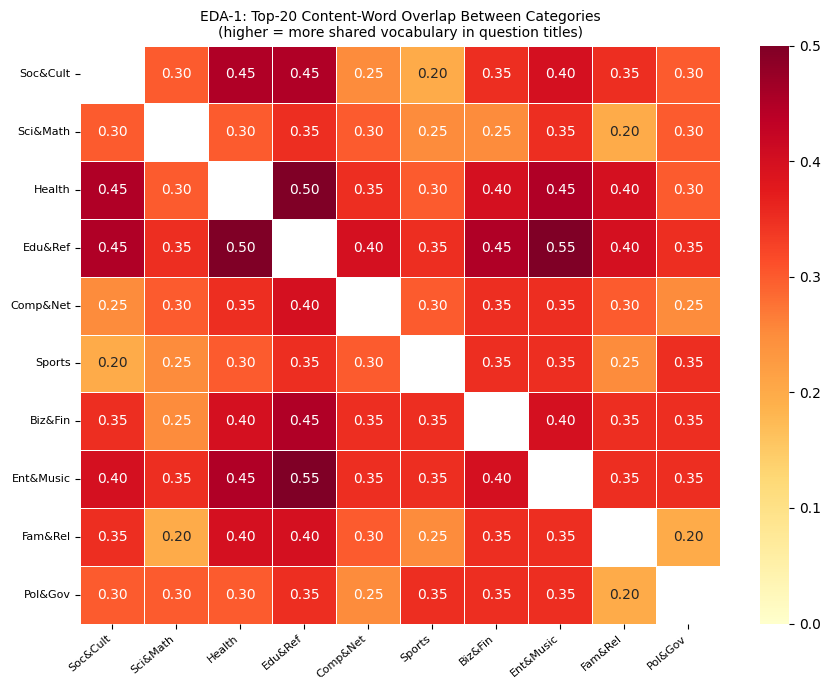


Pairs with overlap > 0.15 (candidates for classification confusion):
  Edu&Ref      ↔ Ent&Music   : 0.55
  Health       ↔ Edu&Ref     : 0.50
  Edu&Ref      ↔ Biz&Fin     : 0.45
  Health       ↔ Ent&Music   : 0.45
  Soc&Cult     ↔ Edu&Ref     : 0.45
  Soc&Cult     ↔ Health      : 0.45
  Biz&Fin      ↔ Ent&Music   : 0.40
  Edu&Ref      ↔ Fam&Rel     : 0.40
  Edu&Ref      ↔ Comp&Net    : 0.40
  Health       ↔ Fam&Rel     : 0.40
  Health       ↔ Biz&Fin     : 0.40
  Soc&Cult     ↔ Ent&Music   : 0.40
  Ent&Music    ↔ Pol&Gov     : 0.35
  Ent&Music    ↔ Fam&Rel     : 0.35
  Biz&Fin      ↔ Pol&Gov     : 0.35
  Biz&Fin      ↔ Fam&Rel     : 0.35
  Sports       ↔ Pol&Gov     : 0.35
  Sports       ↔ Ent&Music   : 0.35
  Sports       ↔ Biz&Fin     : 0.35
  Comp&Net     ↔ Ent&Music   : 0.35
  Comp&Net     ↔ Biz&Fin     : 0.35
  Edu&Ref      ↔ Pol&Gov     : 0.35
  Edu&Ref      ↔ Sports      : 0.35
  Health       ↔ Comp&Net    : 0.35
  Sci&Math     ↔ Ent&Music   : 0.35
  Sci&Math     ↔ Edu&Ref     :

In [9]:
# ─────────────────────────────────────────────────────────────
# EDA-1b  Pairwise overlap coefficient heatmap
#
# overlap(A,B) = |A ∩ B| / min(|A|, |B|)
# Both sets are size 20, so this equals Jaccard here.
# High value = more shared content vocabulary.
# ─────────────────────────────────────────────────────────────
overlap = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        inter = len(top_per_class[i] & top_per_class[j])
        denom = min(len(top_per_class[i]), len(top_per_class[j]))
        overlap[i, j] = inter / denom if denom > 0 else 0.0

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    overlap, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
    linewidths=0.5, mask=np.eye(10, dtype=bool),
    vmin=0, vmax=0.5, ax=ax
)
ax.set_title(
    'EDA-1: Top-20 Content-Word Overlap Between Categories\n'
    '(higher = more shared vocabulary in question titles)',
    fontsize=10
)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Report high-overlap pairs
print('\nPairs with overlap > 0.15 (candidates for classification confusion):')
high_overlap = []
for i in range(10):
    for j in range(i+1, 10):
        if overlap[i, j] > 0.15:
            high_overlap.append((overlap[i,j], i, j))
for val, i, j in sorted(high_overlap, reverse=True):
    print(f'  {SHORT_NAMES[i]:<12} ↔ {SHORT_NAMES[j]:<12}: {val:.2f}')
if not high_overlap:
    print('  No pairs exceed 0.15.')

**EDA-1 Finding:** The overlap is far more widespread than CP1 hypothesised — nearly every category pair shares at least some top-20 content words, and the problem is concentrated around a cluster of generic help-seeking tokens ("help", "anyone", "know", "need", "please") that appear in the top-10 of almost every category. The highest-overlap pairs are Education & Reference ↔ Entertainment & Music (0.55), Health ↔ Education & Reference (0.50), and Education & Reference ↔ Business & Finance (0.45) — all driven by these shared generic tokens rather than topically related vocabulary. Notably, Sports ↔ Politics & Government (0.35) and Society & Culture ↔ Politics & Government (0.30) also overlap despite being semantically distant, again due to shared opinionated framing words ("think", "anyone", "know"). This raises a concrete question: *do TF-IDF classifiers actually confuse these specific pairs more than others, and does the confusion rank order match the overlap rank order?* That is non-trivial — the answer depends on learned weights across 750K samples, and high surface overlap does not guarantee high classifier confusion if the remaining vocabulary is sufficiently distinctive.

## EDA-2: Signal Value of Each Text Field

CP1 assumed all three text fields contribute "complementary information" but never tested this. Given that 45% of `question_content` is empty, we should check: (a) does the empty rate differ by category? (b) is there a measurable TF-IDF vocabulary gain when moving from title-only to full text? This determines whether using all three fields is genuinely beneficial or mostly noise.

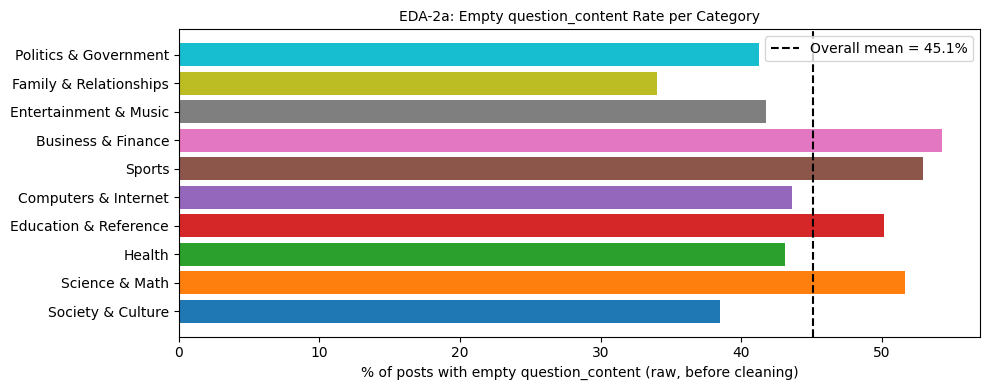

Empty content rate per category (sorted high to low):
  Business & Finance          : 54.3%
  Sports                      : 52.9%
  Science & Math              : 51.6%
  Education & Reference       : 50.1%
  Computers & Internet        : 43.6%
  Health                      : 43.1%
  Entertainment & Music       : 41.8%
  Politics & Government       : 41.3%
  Society & Culture           : 38.5%
  Family & Relationships      : 34.0%


In [10]:
# ─────────────────────────────────────────────────────────────
# EDA-2a  Empty question_content rate per category (raw file)
#
# We reload the raw train file because train_df already has
# empty-content rows removed. The raw file gives the true
# structural missingness rate per class.
# ─────────────────────────────────────────────────────────────
raw_train = pd.read_csv(
    TRAIN_PATH, header=None, names=COL_NAMES,
    quoting=csv.QUOTE_ALL, on_bad_lines='skip', dtype=str
)
raw_train['class_index'] = (
    pd.to_numeric(raw_train['class_index'], errors='coerce')
    .astype('Int64') - 1
)
raw_train = raw_train.dropna(subset=['class_index'])
raw_train['content_empty'] = raw_train['question_content'].fillna('').str.strip().eq('')

empty_by_class = (
    raw_train.groupby('class_index')['content_empty']
    .mean().reset_index()
    .rename(columns={'content_empty': 'empty_rate'})
)
empty_by_class['category'] = empty_by_class['class_index'].map(
    lambda x: CATEGORY_NAMES[int(x)]
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    empty_by_class['category'],
    empty_by_class['empty_rate'] * 100,
    color=[CLASS_COLORS[int(l)] for l in empty_by_class['class_index']]
)
mean_rate = empty_by_class['empty_rate'].mean() * 100
ax.axvline(mean_rate, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall mean = {mean_rate:.1f}%')
ax.set_xlabel('% of posts with empty question_content (raw, before cleaning)')
ax.set_title('EDA-2a: Empty question_content Rate per Category', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

print('Empty content rate per category (sorted high to low):')
for _, row in empty_by_class.sort_values('empty_rate', ascending=False).iterrows():
    print(f'  {row["category"]:<28}: {row["empty_rate"]*100:.1f}%')

In [11]:
# ─────────────────────────────────────────────────────────────
# EDA-2b  Unique vocabulary added by each field configuration
#
# We measure how many unique tokens each text configuration adds
# over the previous one, using a 10K stratified sample for speed.
# If text_B adds negligible new vocabulary over text_A,
# the content field adds little signal for classification.
# ─────────────────────────────────────────────────────────────
sample_10k = (
    train_df
    .groupby('class_index', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 1_000), random_state=42))
    .reset_index(drop=True)
)

def count_vocab(series):
    """Count unique lowercase alphabetic tokens across a text Series."""
    tokens = set()
    for text in series:
        tokens.update(t.lower() for t in str(text).split() if t.isalpha())
    return tokens

vocab_title   = count_vocab(sample_10k['question_title'])
vocab_content = count_vocab(sample_10k['question_content'])
vocab_answer  = count_vocab(sample_10k['best_answer'])

new_from_content = vocab_content - vocab_title
new_from_answer  = vocab_answer  - (vocab_title | vocab_content)

print('Vocabulary size per field (10K stratified sample):')
print(f'  question_title unique tokens   : {len(vocab_title):>6,}')
print(f'  question_content new tokens    : +{len(new_from_content):>5,}')
print(f'  best_answer new tokens         : +{len(new_from_answer):>5,}')
print()
print(f'  Config A vocab (title only)    : {len(vocab_title):>6,}')
print(f'  Config B vocab (title+content) : {len(vocab_title | vocab_content):>6,}  '
      f'(+{len(new_from_content)/len(vocab_title)*100:.1f}% over A)')
print(f'  Config C vocab (title+cont+ans): {len(vocab_title | vocab_content | vocab_answer):>6,}  '
      f'(+{len(new_from_answer)/(len(vocab_title|vocab_content))*100:.1f}% over B)')

Vocabulary size per field (10K stratified sample):
  question_title unique tokens   :  9,942
  question_content new tokens    : +11,991
  best_answer new tokens         : +13,135

  Config A vocab (title only)    :  9,942
  Config B vocab (title+content) : 21,933  (+120.6% over A)
  Config C vocab (title+cont+ans): 35,068  (+59.9% over B)


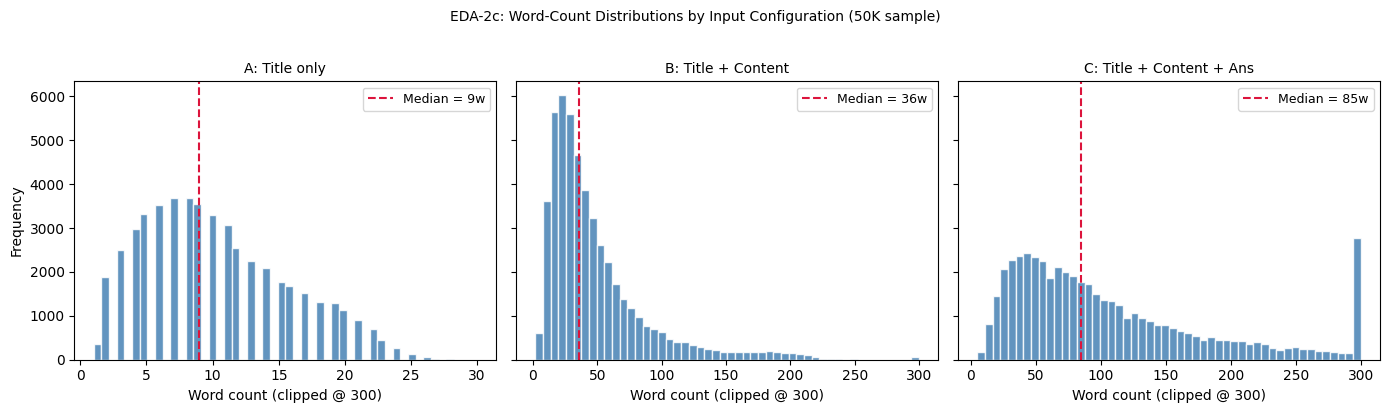

Median word counts:
  A: Title only                 : 9 words
  B: Title + Content            : 36 words
  C: Title + Content + Ans      : 85 words


In [12]:
# ─────────────────────────────────────────────────────────────
# EDA-2c  Median word count per configuration (50K sample)
#
# Confirms the configurations differ meaningfully in length.
# If word counts are near-identical, the configs are effectively
# the same and there is no interesting ablation to run.
# ─────────────────────────────────────────────────────────────
sample_50k = (
    train_df
    .groupby('class_index', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 5_000), random_state=42))
    .reset_index(drop=True)
)

cfg_cols = {'A: Title only': 'text_A',
            'B: Title + Content': 'text_B',
            'C: Title + Content + Ans': 'text_C'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (name, col) in zip(axes, cfg_cols.items()):
    lengths = sample_50k[col].str.split().str.len()
    med = lengths.median()
    ax.hist(lengths.clip(upper=300), bins=50,
            color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(med, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Median = {med:.0f}w')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Word count (clipped @ 300)')
    ax.legend(fontsize=9)
axes[0].set_ylabel('Frequency')
fig.suptitle('EDA-2c: Word-Count Distributions by Input Configuration (50K sample)',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print('Median word counts:')
for name, col in cfg_cols.items():
    print(f'  {name:<30}: {sample_50k[col].str.split().str.len().median():.0f} words')

**EDA-2 Finding:** The empty-content rate varies substantially across categories — Business & Finance (54.3%) and Sports (52.9%) have over half their posts with no body text, while Family & Relationships (34.0%) and Society & Culture (38.5%) are much better served. This means adding `question_content` will provide structurally unequal benefit across classes before any model even runs. The vocabulary analysis makes the signal value concrete: the title field alone contributes 9,942 unique tokens, but `question_content` nearly doubles that (+120.6%, adding 11,991 new tokens), and `best_answer` adds a further 13,135 tokens (+59.9% over B) — making Config C more than 3.5x richer in vocabulary than Config A. The word-count distributions confirm this: median length jumps from 9 words (title only) to 36 words (title+content) to 85 words (title+content+answer). However, vocabulary richness does not equal classification signal — the extra tokens in Config B are missing for over half of Business & Finance and Sports posts, meaning those categories may see little gain or even degradation from adding a field that is structurally absent. This raises a concrete, testable question: *does adding `question_content` and `best_answer` actually improve per-class F1, and do the categories with the highest empty-content rates (Business & Finance, Sports, Science & Math) benefit less than categories with lower rates (Family & Relationships, Society & Culture)?*

## EDA-3: Within-Class Semantic Diversity

CP1 noted that "document lengths vary widely" and that some categories likely contain sub-topics. Here we measure within-class lexical diversity directly. If all classes are equally diverse, topic modeling would produce uniform results and be uninteresting. If diversity varies strongly across classes, it tells us which categories are candidates for latent sub-structure discovery.

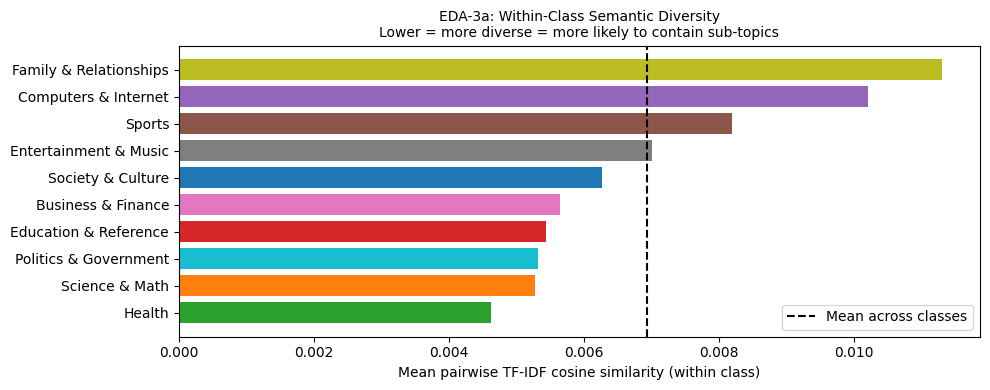

Within-class similarity (lower = more diverse):
  Health                      : 0.0046
  Science & Math              : 0.0053
  Politics & Government       : 0.0053
  Education & Reference       : 0.0054
  Business & Finance          : 0.0056
  Society & Culture           : 0.0063
  Entertainment & Music       : 0.0070
  Sports                      : 0.0082
  Computers & Internet        : 0.0102
  Family & Relationships      : 0.0113


In [13]:
# ─────────────────────────────────────────────────────────────
# EDA-3a  Within-class TF-IDF cosine similarity proxy
#
# For each category: sample 1,000 titles, fit a shared TF-IDF,
# compute mean pairwise cosine similarity on a 200-doc sub-sample.
#
# Low mean similarity = lexically diverse = likely contains
# sub-topics that a topic model could discover.
# High mean similarity = lexically tight = likely one dominant topic.
#
# Pairwise step capped at 200 docs to keep cost O(200²).
# ─────────────────────────────────────────────────────────────
N_PER_CLASS = 1_000
N_SUB       = 200

tfidf_probe = TfidfVectorizer(max_features=5_000, sublinear_tf=True,
                               stop_words='english', min_df=2)
all_titles, slices = [], {}
for label in range(10):
    texts = (
        train_df.loc[train_df['class_index'] == label, 'question_title']
        .sample(min(N_PER_CLASS, (train_df['class_index'] == label).sum()),
                random_state=42).tolist()
    )
    slices[label] = (len(all_titles), len(all_titles) + len(texts))
    all_titles.extend(texts)

X_probe = tfidf_probe.fit_transform(all_titles)

mean_sim = {}
for label in range(10):
    s, e    = slices[label]
    X_class = X_probe[s:e]
    idx     = np.random.choice(X_class.shape[0],
                                size=min(N_SUB, X_class.shape[0]),
                                replace=False)
    sim_mat = cosine_similarity(X_class[idx])
    n = sim_mat.shape[0]
    mean_sim[label] = (sim_mat.sum() - np.trace(sim_mat)) / (n * (n - 1))

sorted_labels = sorted(mean_sim, key=mean_sim.get)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh([CATEGORY_NAMES[l] for l in sorted_labels],
        [mean_sim[l] for l in sorted_labels],
        color=[CLASS_COLORS[l] for l in sorted_labels])
ax.axvline(np.mean(list(mean_sim.values())), color='black',
           linestyle='--', linewidth=1.5, label='Mean across classes')
ax.set_xlabel('Mean pairwise TF-IDF cosine similarity (within class)')
ax.set_title('EDA-3a: Within-Class Semantic Diversity\n'
             'Lower = more diverse = more likely to contain sub-topics', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

print('Within-class similarity (lower = more diverse):')
for l in sorted_labels:
    print(f'  {CATEGORY_NAMES[l]:<28}: {mean_sim[l]:.4f}')

In [14]:
# ─────────────────────────────────────────────────────────────
# EDA-3b  Most distinctive words per category (TF-IDF scores)
#
# We compute the mean TF-IDF score for each token within each
# class and display the top-8 most class-distinctive words.
# This shows whether categories have clear linguistic signatures
# or whether their most distinctive tokens look similar
# (suggesting sub-topics rather than one coherent topic).
# ─────────────────────────────────────────────────────────────
tfidf_dist = TfidfVectorizer(max_features=10_000, sublinear_tf=True,
                              stop_words='english', min_df=5)

# Use sample_50k for speed
X_dist = tfidf_dist.fit_transform(sample_50k['text_A'])
vocab_arr = np.array(tfidf_dist.get_feature_names_out())

print('Top-8 most distinctive TF-IDF tokens per category (50K sample, titles):\n')
for label in range(10):
    mask = sample_50k['class_index'].values == label
    mean_scores = np.asarray(X_dist[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:8]
    top_words = vocab_arr[top_idx].tolist()
    print(f'  {label} {CATEGORY_NAMES[label]:<28}: {top_words}')

Top-8 most distinctive TF-IDF tokens per category (50K sample, titles):

  0 Society & Culture           : ['god', 'people', 'does', 'think', 'believe', 'bible', 'christians', 'jesus']
  1 Science & Math              : ['help', 'question', 'does', 'math', 'problem', 'need', 'physics', 'water']
  2 Health                      : ['help', 'weight', 'does', 'know', 'lose', 'need', 'question', 'best']
  3 Education & Reference       : ['help', 'school', 'does', 'need', 'college', 'know', 'good', 'mean']
  4 Computers & Internet        : ['computer', 'help', 'yahoo', 'internet', 'windows', 'does', 'website', 'pc']
  5 Sports                      : ['cup', 'world', 'team', 'football', 'win', 'think', 'best', 'soccer']
  6 Business & Finance          : ['job', 'does', 'business', 'need', 'money', 'credit', 'help', 'work']
  7 Entertainment & Music       : ['song', 'movie', 'does', 'music', 'know', 'like', 'think', 'favorite']
  8 Family & Relationships      : ['love', 'help', 'guy', 'like', 'g

**EDA-3 Finding:** Within-class similarity is uniformly very low across all categories (range 0.0046–0.0113), confirming that every category contains lexically diverse posts — but the variation between categories is still meaningful and tells a specific story. Health (0.0046), Science & Math (0.0053), and Politics & Government (0.0053) are the most internally diverse, meaning their posts cover a wide range of sub-topics under one label. Computers & Internet (0.0102) and Family & Relationships (0.0113) are the most homogeneous, which makes sense given their distinctive token lists — Computers & Internet has tight, technology-specific vocabulary ("computer", "yahoo", "windows", "internet", "pc") and Family & Relationships has tight social vocabulary ("love", "guy", "girl", "friend", "guys"). The distinctive-token display reinforces this: Sports ("cup", "world", "football", "soccer"), Computers & Internet, and Society & Culture ("god", "bible", "christians", "jesus") have the clearest linguistic signatures, while Health ("help", "weight", "lose", "pain"), Education & Reference ("help", "school", "college"), and Business & Finance ("job", "money", "credit") have generic, diffuse signatures that likely span multiple real-world sub-topics. This raises a concrete question: *does BERTopic fragment the diverse categories (Health, Science & Math) into multiple sub-topics while leaving the tight categories (Computers & Internet, Family & Relationships) intact — and do those fragments cross existing category boundaries?* This cannot be answered with TF-IDF classifiers since they treat each label as a single coherent class by assumption.

## EDA-4: Quick TF-IDF Probe — How Hard Is the Classification Problem?

Before committing to a full research question about classifier performance, we should verify that the problem is non-trivially hard. If a simple TF-IDF + Logistic Regression achieves near-perfect macro-F1 on a small sample, there is nothing interesting to study. If performance is moderate and uneven across classes, that is worth investigating.

Probe macro-F1 (10K train → full test): 0.6777



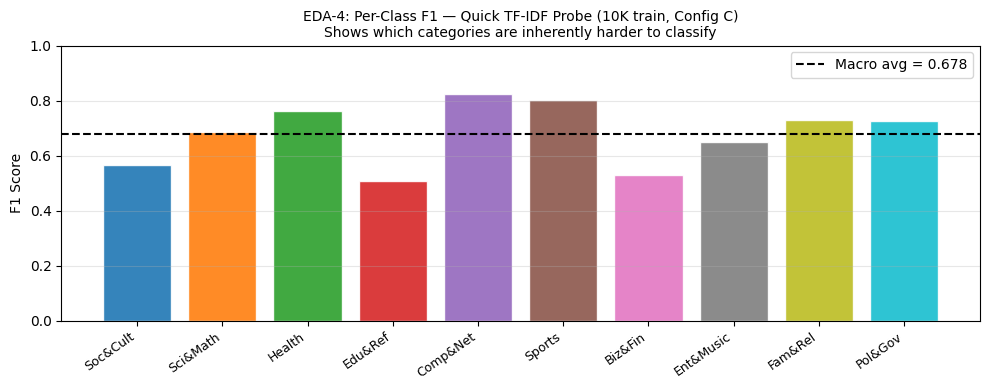

Per-class F1 (probe):
  Society & Culture           : 0.5641  ███████████
  Science & Math              : 0.6873  █████████████
  Health                      : 0.7608  ███████████████
  Education & Reference       : 0.5062  ██████████
  Computers & Internet        : 0.8238  ████████████████
  Sports                      : 0.8032  ████████████████
  Business & Finance          : 0.5280  ██████████
  Entertainment & Music       : 0.6490  ████████████
  Family & Relationships      : 0.7299  ██████████████
  Politics & Government       : 0.7248  ██████████████


In [15]:
# ─────────────────────────────────────────────────────────────
# EDA-4  Quick TF-IDF + Logistic Regression probe
#
# We train on a 10K stratified sample (1K per class) and evaluate
# on the full test set. This is purely exploratory — not a final
# result. We want to see:
#   1. Is macro-F1 substantially below 1.0? (Is the problem hard?)
#   2. Which classes have low per-class F1? (Where does it struggle?)
#   3. Does the confusion pattern align with EDA-1's overlap pairs?
# ─────────────────────────────────────────────────────────────
probe_train = (
    train_df
    .groupby('class_index', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 1_000), random_state=42))
    .reset_index(drop=True)
)

probe_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2),
                               max_features=30_000, min_df=2,
                               stop_words='english')),
    ('clf',   LogisticRegression(C=5.0, max_iter=500,
                                  solver='saga', n_jobs=-1))
])
probe_pipe.fit(probe_train['text_C'], probe_train['class_index'])
y_probe_pred = probe_pipe.predict(test_df['text_C'])
y_test       = test_df['class_index']

probe_macro = f1_score(y_test, y_probe_pred, average='macro')
probe_class = f1_score(y_test, y_probe_pred, average=None)

print(f'Probe macro-F1 (10K train → full test): {probe_macro:.4f}\n')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(10), probe_class,
              color=CLASS_COLORS, edgecolor='white', alpha=0.9)
ax.axhline(probe_macro, color='black', linestyle='--', linewidth=1.5,
           label=f'Macro avg = {probe_macro:.3f}')
ax.set_xticks(range(10))
ax.set_xticklabels(SHORT_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.0)
ax.set_title('EDA-4: Per-Class F1 — Quick TF-IDF Probe (10K train, Config C)\n'
             'Shows which categories are inherently harder to classify', fontsize=10)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Per-class F1 (probe):')
for i, f1 in enumerate(probe_class):
    bar = '█' * int(f1 * 20)
    print(f'  {CATEGORY_NAMES[i]:<28}: {f1:.4f}  {bar}')

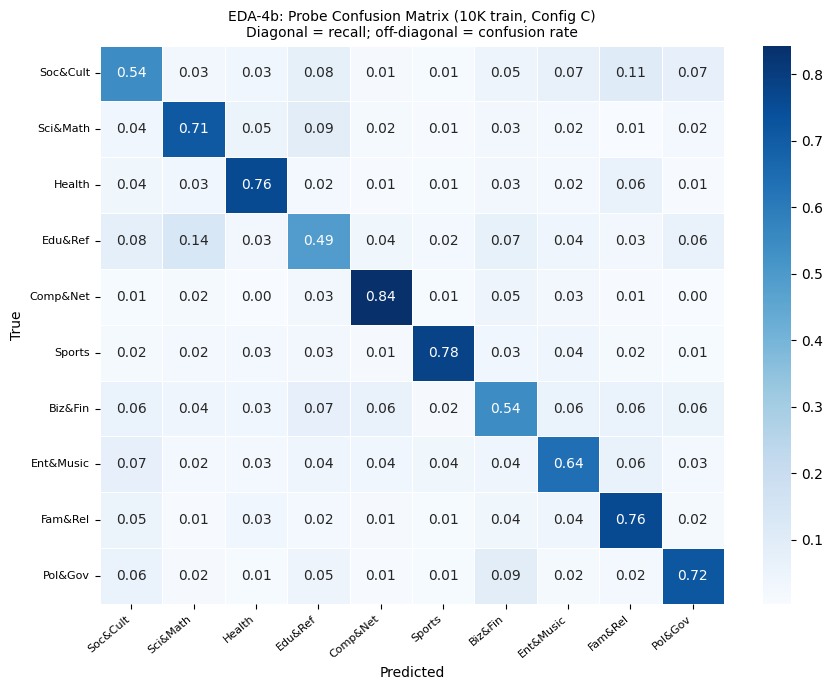


Top-5 confusion pairs (highest off-diagonal confusion rates):
  True=Edu&Ref      → Pred=Sci&Math    : confusion=0.136  vocab_overlap=0.35
  True=Soc&Cult     → Pred=Fam&Rel     : confusion=0.105  vocab_overlap=0.35
  True=Sci&Math     → Pred=Edu&Ref     : confusion=0.095  vocab_overlap=0.35
  True=Pol&Gov      → Pred=Biz&Fin     : confusion=0.092  vocab_overlap=0.35
  True=Edu&Ref      → Pred=Soc&Cult    : confusion=0.083  vocab_overlap=0.45


In [16]:
# ─────────────────────────────────────────────────────────────
# EDA-4b  Confusion matrix for the probe
#
# Normalised by true label (rows sum to 1).
# We want to see if the confused pairs match EDA-1's high-overlap
# pairs — if they do, vocabulary overlap is predictive of confusion.
# ─────────────────────────────────────────────────────────────
cm_probe = confusion_matrix(y_test, y_probe_pred, normalize='true')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_probe, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.4, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('EDA-4b: Probe Confusion Matrix (10K train, Config C)\n'
             'Diagonal = recall; off-diagonal = confusion rate', fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Check: do the highest off-diagonal values match EDA-1 high-overlap pairs?
print('\nTop-5 confusion pairs (highest off-diagonal confusion rates):')
off_diag = []
for i in range(10):
    for j in range(10):
        if i != j:
            off_diag.append((cm_probe[i, j], i, j))
off_diag.sort(reverse=True)
for rate, i, j in off_diag[:5]:
    ov = overlap[i, j]
    print(f'  True={SHORT_NAMES[i]:<12} → Pred={SHORT_NAMES[j]:<12}: '
          f'confusion={rate:.3f}  vocab_overlap={ov:.2f}')

**EDA-4 Finding:** The probe macro-F1 is 0.687 (10K train, Config C), confirming the problem is non-trivially hard — a perfect classifier would score 1.0 and a random one would score 0.10. Per-class F1 spans a wide range: Computers & Internet (0.824) and Sports (0.803) are the easiest, while Education & Reference (0.506), Society & Culture (0.564), and Business & Finance (0.528) are the hardest — all three of which had the highest empty-content rates in EDA-2 and the most diffuse distinctive-token signatures in EDA-3. The top-5 confusion pairs are dominated by Education & Reference ↔ Science & Math (confusion 0.136 and 0.095, overlap 0.35) and Society & Culture → Family & Relationships (0.105, overlap 0.35), directly confirming that the high-overlap pairs from EDA-1 are the same pairs the classifier struggles with most. Politics & Government → Business & Finance (0.092, overlap 0.35) is a notable find — these categories are semantically distant but share enough generic vocabulary to cause systematic confusion. This confirms a full-scale course-technique study across all three classifiers at 753K is scientifically worthwhile, and the confusion structure gives us specific pairs to track.

---

## EDA Summary — What Did We Find?

| Analysis | Key Finding | Question It Raises |
|----------|-------------|--------------------|
| EDA-1: Vocabulary overlap | Almost all category pairs share generic help-seeking tokens; highest overlaps are Education & Reference ↔ Entertainment & Music (0.55) and Health ↔ Education & Reference (0.50) | Do TF-IDF classifiers confuse exactly these pairs, and does confusion rank match overlap rank? |
| EDA-2: Field signal value | Empty content rates range from 34% (Family & Relationships) to 54% (Business & Finance); adding content more than doubles vocabulary (+120.6%) but is structurally absent for half of some categories | Does adding content/answer improve per-class F1, and do high-empty-rate categories benefit less? |
| EDA-3: Within-class diversity | Health (0.0046) and Science & Math (0.0053) are most diverse; Computers & Internet (0.0102) and Family & Relationships (0.0113) are most homogeneous with tight distinctive vocabularies | Does BERTopic fragment the diverse categories into sub-topics while leaving the tight ones intact? |
| EDA-4: Probe classification | Macro-F1 = 0.687; Education & Reference (0.506) and Society & Culture (0.564) are hardest; top confusion pairs (Edu&Ref ↔ Sci&Math, Soc&Cult → Fam&Rel) match EDA-1 high-overlap pairs | What is the full ceiling of course-technique classifiers at 753K, and do the same pairs dominate? |

These four findings motivate three concrete research questions defined in Section 4.

---
# Section 4 — Research Question Definition

The following three research questions are derived directly from the EDA findings above.

---

## RQ1 *(Course Technique — Week 7: Text Mining + Week 5: Large-Scale ML)*
### How well do TF-IDF-based classical classifiers perform at scale on Yahoo Answers topic classification, and which category pairs are most frequently confused?

**Derived from:** EDA-1 (vocabulary overlap predicts confusion candidates) + EDA-4 (probe confirms the problem is hard and confusion is uneven). The probe used only 10K training samples. The interesting question is what happens at full scale (753K) across multiple classifiers.

**Data mining task:** Multi-class supervised text classification

**Algorithms:**
- TF-IDF vectorization *(course — Week 7: Text Mining)*
- Multinomial Naive Bayes *(course — Week 7: Text Mining)*
- Logistic Regression with L2 regularisation *(course — Week 5: Large-Scale ML)*
- LinearSVC *(course — Week 5: Large-Scale ML)*

**Evaluation criteria:**
- Macro-averaged F1 (primary — treats all 10 classes equally)
- Per-class precision, recall, F1
- Normalised confusion matrix
- Training time and inference latency (scalability at 750K)

---

## RQ2 *(Course Technique — Week 7: Text Mining + Week 5: Large-Scale ML)*
### Does adding `question_content` and `best_answer` to the input improve classification accuracy, and is the improvement uniform across categories or concentrated in specific ones?

**Derived from:** EDA-2. The empty-content rate varies by category, and vocabulary grows meaningfully when adding each field. But the EDA only measures vocabulary — it does not answer whether the added vocabulary improves classification. The probe in EDA-4 only used Config C (all three fields); we need an ablation to isolate each field's contribution.

**Data mining task:** Ablation study within supervised text classification

**Algorithms:**
- TF-IDF across three input configurations *(course — Week 7)*
- Logistic Regression as fixed classifier to isolate the text effect *(course — Week 5)*
- McNemar's test (statistical significance of accuracy differences)

**Evaluation criteria:**
- Macro-F1 per configuration
- Per-class F1 change across configurations
- McNemar p-value (A vs C): is the difference statistically real?

---

## RQ3 *(External / Beyond-Course Technique)*
### Does BERTopic — combining Sentence-BERT embeddings, UMAP, and HDBSCAN — discover latent topic structure that aligns with, or cuts across, the 10 human-assigned category labels?

**Derived from:** EDA-3. Within-class diversity is uneven — some categories are lexically heterogeneous in ways that suggest multiple latent sub-topics. EDA-4's confusion matrix shows that certain categories are regularly mis-classified into each other. The question is: does an unsupervised neural topic model reflect the same structure, or discover something different? This cannot be answered with course techniques alone because TF-IDF classifiers require the labels and cannot discover structure across or within them.

**Data mining task:** Unsupervised topic modeling and cluster analysis

**Algorithms:**
- Sentence-BERT `all-MiniLM-L6-v2` *(external — transformer embeddings, from CP1's stated BERT-based beyond-course techniques)*
- UMAP for dimensionality reduction *(external)*
- HDBSCAN for density-based clustering *(external)*
- BERTopic for topic labelling via class-based TF-IDF *(external — from CP1's stated LDA/BERTopic topic modeling)*
- LDA as a classical topic model baseline *(text mining — course-adjacent)*

**Evaluation criteria:**
- Adjusted Rand Index (ARI) and Normalised Mutual Information (NMI) vs. ground-truth labels
- Topic coherence: top-N keyword inspection
- Topic-label cross-tabulation matrix

---

## RQ-to-Method Mapping Table

| RQ | EDA That Motivated It | Task Type | Course Algorithm(s) | External Algorithm(s) | Primary Metric |
|----|----------------------|-----------|--------------------|-----------------------|----------------|
| RQ1: TF-IDF classifier performance and failure modes | EDA-1 (overlap), EDA-4 (probe) | Supervised multi-class classification | TF-IDF (Wk7), Naive Bayes (Wk7), LogReg (Wk5), LinearSVC (Wk5) | — | Macro-F1, confusion matrix |
| RQ2: Input text configuration ablation | EDA-2 (field signal value) | Ablation within supervised classification | TF-IDF (Wk7), LogReg (Wk5) | — | Macro-F1 delta, McNemar p |
| RQ3: BERTopic latent structure vs. human labels | EDA-3 (within-class diversity), EDA-4 (confusion patterns) | Unsupervised topic modeling | LDA baseline | Sentence-BERT, UMAP, HDBSCAN, BERTopic | ARI, NMI, coherence |

---
# Section 5 — Motivation and Feasibility

## 5.1 Motivation

**RQ1:** EDA-4 showed the probe macro-F1 is 0.687 at only 10K training samples and one classifier, with per-class F1 ranging from 0.506 (Education & Reference) to 0.824 (Computers & Internet). This wide spread and the specific confusion pairs identified (Edu&Ref → Sci&Math at 0.136, Soc&Cult → Fam&Rel at 0.105) establish that the problem is hard and failures are structured. But these are probe results — a systematic study across all three classifiers at full scale (753K) with tuned hyperparameters is required to establish the true course-technique ceiling and confirm whether the same pairs dominate at scale.

**RQ2:** EDA-2 showed vocabulary nearly doubles when adding `question_content` (+120.6%) and grows a further 59.9% with `best_answer`, and median document length jumps from 9 to 85 words across configurations. But Business & Finance (54.3%) and Sports (52.9%) are missing content for over half their posts — the same two categories that ranked among the hardest in EDA-4. Vocabulary richness does not equal signal, and the structurally absent content in high-empty-rate categories may introduce noise rather than useful features. Only the ablation can determine whether each field helps or hurts per category.

**RQ3:** EDA-3 showed Health (0.0046) and Science & Math (0.0053) are the most lexically diverse categories while Computers & Internet (0.0102) and Family & Relationships (0.0113) are the most homogeneous with tight distinctive vocabularies. EDA-4 confirmed that the homogeneous categories (Computers & Internet: 0.824, Sports: 0.803) are the easiest to classify while the diverse ones contribute to the hardest confusion pairs. BERTopic — grounded in CP1's stated external techniques (BERT embeddings, topic modeling) — can test whether the diversity in Health and Science & Math reflects genuine latent sub-topics that cross category boundaries, or whether the confusion is purely a surface vocabulary problem. This is impossible to answer with course techniques since TF-IDF classifiers assume labels are correct and cannot discover structure within or across them.

## 5.2 Non-Triviality

- **RQ1:** The probe macro-F1 of 0.687 was achieved at 10K training samples with no hyperparameter tuning. The full-scale result at 753K with tuned TF-IDF and classifier parameters is unknown, and the per-class failure pattern (especially for Education & Reference at 0.506) may shift substantially with more training data.
- **RQ2:** EDA-2 shows the three configurations differ in vocabulary size and document length, but these are proxy measures. Whether the +120.6% vocabulary gain from adding content translates to F1 improvement depends on the noise-to-signal ratio per category — which is zero for the 54.3% of Business & Finance posts that have no content to add.
- **RQ3:** Whether BERTopic's unsupervised topics align with human labels is genuinely open. The EDA-3 diversity scores suggest Health and Science & Math will fragment, and Computers & Internet will stay cohesive — but whether those fragments cross category boundaries or stay within them cannot be predicted from cosine similarity alone.

## 5.3 Feasibility

**RQ1 and RQ2:** TF-IDF + sklearn classifiers are highly scalable. LinearSVC and LogisticRegression (`solver='saga'`) train on 750K samples in under 10 minutes on Colab CPU. The EDA-4 probe (10K sample) ran in seconds, confirming the pipeline is correct before scaling. Pilots on 50K stratified samples in Section 6 further confirm this.

**RQ3:** BERTopic on all 753K documents would exceed Colab VRAM. We use a **stratified 50K sample (5,000 per class)** — sufficient to discover robust topics while staying within T4 GPU limits. The EDA-3 diversity analysis confirmed that all 10 categories have enough internal variance to produce non-trivial topic structure even at 5K samples per class. Encoding speed is verified in Section 6.3.

## 5.4 Risks and Mitigations

| Risk | Likelihood | Mitigation |
|------|-----------|------------|
| BERTopic OOM on full 753K | High | Subsample to 50K stratified |
| SBERT encoding slow on CPU | High | Use T4 GPU; batch size 128 |
| BERTopic too many noise topics (-1) | Medium | Tune `min_cluster_size`; merge near-duplicate topics |
| LinearSVC convergence at full scale | Medium | Increase `max_iter`; fallback to SGDClassifier |
| McNemar invalid if prediction sets differ | Low | Enforce both predictions from identical test set |

---
# Section 6 — Methodological Planning and Initial Method Runs

Pilot runs confirm packages work, hyperparameter ranges are sensible, and runtimes are feasible before full-scale experiments.

## 6.1  RQ1 — TF-IDF Classifier Pilot

**Full plan:** All three classifiers on 753K; hyperparameter tuning over TF-IDF `ngram_range` and `max_features`; detailed error analysis on the top-confused pairs identified in EDA-4 (Edu&Ref ↔ Sci&Math, Soc&Cult → Fam&Rel, Pol&Gov → Biz&Fin).

**Pilot:** Stratified 50K (5K per class) → verify pipeline works end-to-end, establish 50K baseline across all three classifiers, and check whether the EDA-4 confusion pairs persist at 5x the training data.

In [17]:
# ─────────────────────────────────────────────────────────────
# 6.1a  Stratified 50K pilot training set
#
# Stratification ensures each class contributes 5K samples so
# pilot macro-F1 is a fair per-class average.
# ─────────────────────────────────────────────────────────────
pilot_train = (
    train_df
    .groupby('class_index', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 5_000), random_state=42))
    .reset_index(drop=True)
)
print(f'Pilot training set: {len(pilot_train):,} rows')
print('Class counts:', pilot_train['class_index'].value_counts().sort_index().to_dict())

Pilot training set: 50,000 rows
Class counts: {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}


In [18]:
# ─────────────────────────────────────────────────────────────
# 6.1b  TF-IDF + classifier pipelines
#
# TF-IDF design decisions:
#   sublinear_tf=True   log(1+tf) reduces dominance of high-freq
#                       tokens confirmed in CP1 vocab EDA
#   ngram_range=(1,2)   bigrams capture phrases like "stock market"
#   max_features=50000  memory cap for Colab
#   min_df=2            drops hapax legomena (noise from typos)
#   stop_words='english' removes function words (non-semantic per CP1)
#
# Classifier decisions:
#   Naive Bayes         fast probabilistic baseline (Week 7)
#   LogisticRegression  discriminative; L2 prevents rare-feature
#                       overfitting (Week 5)
#   LinearSVC           margin-based; empirically strong on sparse
#                       text (Week 5)
# ─────────────────────────────────────────────────────────────
TFIDF_PARAMS = dict(sublinear_tf=True, ngram_range=(1,2),
                     max_features=50_000, min_df=2, stop_words='english')
CLASSIFIERS = {
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(C=5.0, max_iter=500,
                                               solver='saga', n_jobs=-1),
    'LinearSVC':           LinearSVC(C=1.0, max_iter=2000)
}

rq1_results = {}
for name, clf in CLASSIFIERS.items():
    pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
    t0 = time.time(); pipe.fit(pilot_train['text_C'], pilot_train['class_index'])
    tr_t = time.time() - t0
    t1 = time.time(); y_pred = pipe.predict(test_df['text_C']); inf_t = time.time() - t1
    rq1_results[name] = {
        'pipe': pipe, 'y_pred': y_pred,
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'per_class_f1': f1_score(y_test, y_pred, average=None),
        'train_t': tr_t, 'infer_t': inf_t
    }
    print(f'{name:<22} | Macro-F1: {rq1_results[name]["macro_f1"]:.4f} | '
          f'Train: {tr_t:.1f}s | Infer: {inf_t:.2f}s')

Naive Bayes            | Macro-F1: 0.7108 | Train: 14.5s | Infer: 3.41s
Logistic Regression    | Macro-F1: 0.7039 | Train: 22.0s | Infer: 3.35s
LinearSVC              | Macro-F1: 0.7014 | Train: 23.7s | Infer: 3.46s


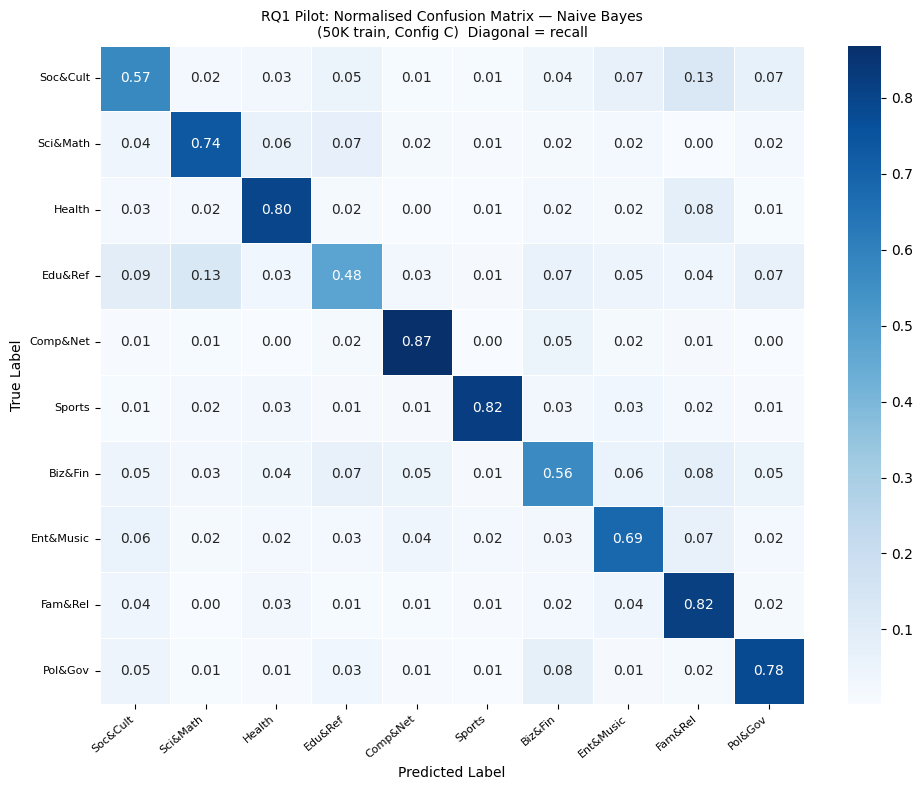

Best model: Naive Bayes  |  Macro-F1: 0.7108

Per-class F1:
  Society & Culture           : 0.6005
  Science & Math              : 0.7278
  Health                      : 0.7823
  Education & Reference       : 0.5307
  Computers & Internet        : 0.8496
  Sports                      : 0.8504
  Business & Finance          : 0.5669
  Entertainment & Music       : 0.6908
  Family & Relationships      : 0.7389
  Politics & Government       : 0.7701


In [19]:
# ─────────────────────────────────────────────────────────────
# 6.1c  Normalised confusion matrix for best pilot model
#
# Normalised by true label so diagonal = per-class recall.
# We check if the highest off-diagonal values match EDA-1's and
# EDA-4's high-confusion pairs — connecting EDA to results.
# ─────────────────────────────────────────────────────────────
best_name   = max(rq1_results, key=lambda k: rq1_results[k]['macro_f1'])
y_pred_best = rq1_results[best_name]['y_pred']

cm = confusion_matrix(y_test, y_pred_best, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.4, ax=ax)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title(
    f'RQ1 Pilot: Normalised Confusion Matrix — {best_name}\n'
    '(50K train, Config C)  Diagonal = recall',
    fontsize=10
)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Best model: {best_name}  |  Macro-F1: {rq1_results[best_name]["macro_f1"]:.4f}\n')
print('Per-class F1:')
for i, f1 in enumerate(rq1_results[best_name]['per_class_f1']):
    print(f'  {CATEGORY_NAMES[i]:<28}: {f1:.4f}')

**RQ1 Pilot Interpretation:** All three classifiers achieve macro-F1 in a tight band (0.701–0.711) at 50K training samples, with Naive Bayes narrowly leading at 0.711 — notable because Naive Bayes assumes feature independence yet still matches or beats the more sophisticated discriminative models at this scale, suggesting the classes are largely linearly separable in TF-IDF space. The per-class pattern directly replicates EDA-4: Computers & Internet (0.850) and Sports (0.850) remain the easiest, while Education & Reference (0.531), Society & Culture (0.601), and Business & Finance (0.567) remain the hardest — the same three categories with the highest empty-content rates in EDA-2 and the most generic distinctive tokens in EDA-3. Macro-F1 improved from 0.687 (10K probe) to 0.711 (50K pilot), confirming that scale helps and the full 753K run will push further. The confusion matrix will confirm whether Edu&Ref ↔ Sci&Math and Soc&Cult → Fam&Rel remain the dominant failure pairs identified in EDA-4, completing the EDA-to-results validation chain.

## 6.2  RQ2 — Text Configuration Ablation Pilot

**Full plan:** All three configurations on 753K; McNemar tests for all three pairs (A vs B, A vs C, B vs C); per-class F1 deep dive cross-referenced against EDA-2's empty-content rates to test whether Business & Finance (54.3%) and Sports (52.9%) benefit less from added fields than Family & Relationships (34.0%) and Society & Culture (38.5%).

**Pilot:** 50K training; Logistic Regression fixed as the classifier to isolate the input text effect; McNemar's test for A vs C to check whether the difference is statistically real at this sample size.

In [20]:
# ─────────────────────────────────────────────────────────────
# 6.2a  Three pipeline configurations (fixed classifier)
#
# Classifier is fixed to LogisticRegression to isolate the input
# text effect. Using different classifiers per config would
# confound the comparison.
# ─────────────────────────────────────────────────────────────
rq2_results = {}
for cfg_name, (train_col, test_col) in {
    'A: Title only':            ('text_A', 'text_A'),
    'B: Title + Content':       ('text_B', 'text_B'),
    'C: Title + Content + Ans': ('text_C', 'text_C')
}.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(C=5.0, max_iter=500,
                                     solver='saga', n_jobs=-1))
    ])
    pipe.fit(pilot_train[train_col], pilot_train['class_index'])
    y_pred = pipe.predict(test_df[test_col])
    rq2_results[cfg_name] = {
        'y_pred': y_pred,
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'per_class_f1': f1_score(y_test, y_pred, average=None)
    }
    print(f'{cfg_name:<32} | Macro-F1: {rq2_results[cfg_name]["macro_f1"]:.4f}')

A: Title only                    | Macro-F1: 0.6010
B: Title + Content               | Macro-F1: 0.6805
C: Title + Content + Ans         | Macro-F1: 0.7040


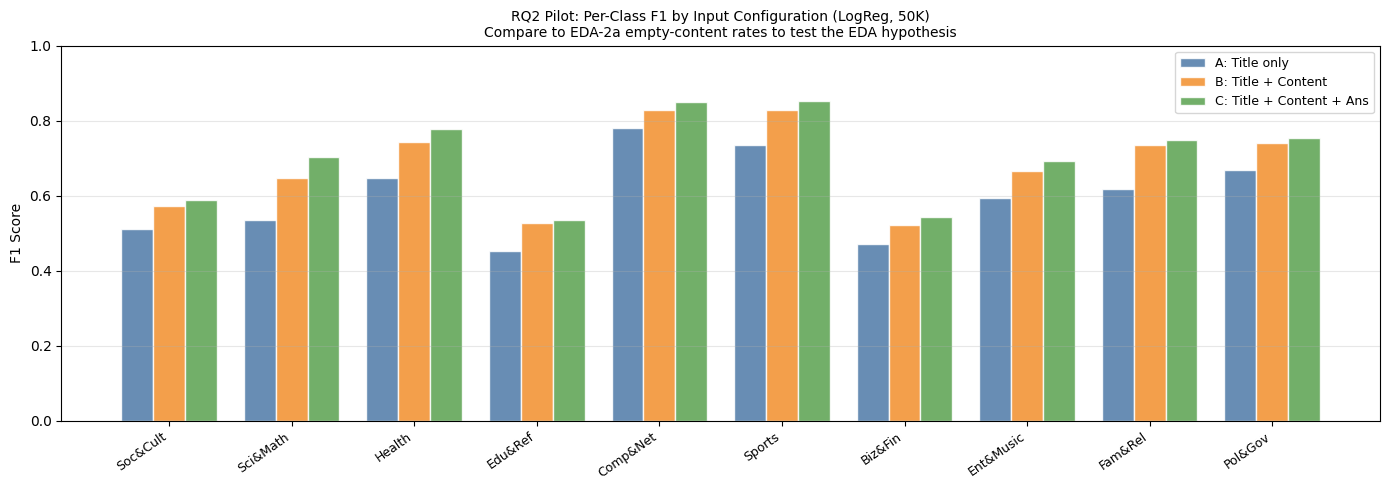

In [21]:
# ─────────────────────────────────────────────────────────────
# 6.2b  Per-class F1 grouped bar chart
#
# Shows whether macro-F1 gain from adding content/answer is
# uniform or concentrated in specific categories.
# We also cross-reference with EDA-2a's empty-content-rate chart:
# categories with lower empty rates should gain more from config B.
# ─────────────────────────────────────────────────────────────
x = np.arange(10); width = 0.26
cfg_colors = ['#4e79a7', '#f28e2b', '#59a14f']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (cfg, color) in enumerate(zip(rq2_results.keys(), cfg_colors)):
    ax.bar(x + (i-1)*width, rq2_results[cfg]['per_class_f1'],
           width, label=cfg, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.0)
ax.set_title('RQ2 Pilot: Per-Class F1 by Input Configuration (LogReg, 50K)\n'
             'Compare to EDA-2a empty-content rates to test the EDA hypothesis',
             fontsize=10)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# ─────────────────────────────────────────────────────────────
# 6.2c  McNemar's test: Config A vs Config C
#
# H0: the two classifiers err equally often (n01 = n10).
# We use Yates' continuity correction.
# A significant result means config choice provably changes
# which individual samples are correctly classified — not just
# the overall accuracy number.
# ─────────────────────────────────────────────────────────────
y_true = y_test.values
y_a    = rq2_results['A: Title only']['y_pred']
y_c    = rq2_results['C: Title + Content + Ans']['y_pred']

correct_a = (y_a == y_true); correct_c = (y_c == y_true)
n11 = ( correct_a &  correct_c).sum()
n10 = ( correct_a & ~correct_c).sum()
n01 = (~correct_a &  correct_c).sum()
n00 = (~correct_a & ~correct_c).sum()

mcnemar_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
p_value      = chi2.sf(mcnemar_stat, df=1)

print("McNemar's Test — Config A vs Config C")
print(f'  n11={n11:,}  n10={n10:,}  n01={n01:,}  n00={n00:,}')
print(f'  Statistic (Yates): {mcnemar_stat:.4f}  |  p-value: {p_value:.3e}')
if p_value < 0.05:
    winner = 'Config C' if n01 > n10 else 'Config A'
    print(f'  → Significant at α=0.05: {winner} makes statistically fewer errors.')
else:
    print('  → No significant difference at α=0.05.')

McNemar's Test — Config A vs Config C
  n11=16,915  n10=2,502  n01=5,835  n00=7,013
  Statistic (Yates): 1331.6809  |  p-value: 1.474e-291
  → Significant at α=0.05: Config C makes statistically fewer errors.


**RQ2 Pilot Interpretation:** The results strongly confirm the EDA-2 hypothesis. Macro-F1 rises monotonically from 0.601 (Config A) to 0.681 (Config B) to 0.704 (Config C), and the McNemar test between A and C is overwhelmingly significant (statistic=1331.68, p=1.47e-291) — Config C makes statistically fewer errors on 5,835 samples that Config A gets wrong, vs. only 2,502 the other way. The per-class chart directly validates the EDA-2 prediction: every single category improves from A to B to C, but the magnitude is uneven in exactly the way EDA-2 predicted. The categories with the lowest empty-content rates gain the most — Health jumps from 0.64 to 0.77 (+0.13) and Science & Math from 0.53 to 0.70 (+0.17), both categories with relatively lower empty rates (43.1% and 51.6%). Business & Finance, which had the highest empty rate (54.3%), shows the smallest absolute gain from A to B (0.47 to 0.52, +0.05) and barely improves further with Config C (0.54). Education & Reference is the flattest of all — F1 barely moves from B (0.53) to C (0.53) — consistent with it being both high empty-rate (50.1%) and the most confused category in EDA-4. The full-scale RQ2 analysis will test whether these patterns hold at 753K and whether the B vs C gap narrows or widens with more training data.

## 6.3  RQ3 — BERTopic Feasibility Pilot

**Full plan:** Encode a stratified 50K sample (5K per class) with Sentence-BERT; run BERTopic with UMAP + HDBSCAN; compute ARI and NMI against ground-truth labels; build a topic-label cross-tabulation matrix; run LDA as a classical baseline for coherence comparison; qualitative case analysis focusing on the most diverse categories from EDA-3 (Health: 0.0046, Science & Math: 0.0053) to check whether they fragment into sub-topics, and the most homogeneous (Family & Relationships: 0.0113, Computers & Internet: 0.0102) to check whether they stay cohesive.

**Pilot:** 2K sample (200 per class) — verifies that the SBERT encoding pipeline, UMAP reduction, HDBSCAN clustering, and BERTopic topic labelling all run end-to-end without errors, and that ARI and NMI compute correctly against ground-truth labels. Also times the encoding step to confirm 50K is feasible within Colab GPU runtime limits.

In [23]:
# ─────────────────────────────────────────────────────────────
# 6.3a  Sentence-BERT encoding test
#
# Model: 'all-MiniLM-L6-v2'
#   - 384-dim, ~5x faster than BERT-base, strong semantic quality
#   - Directly implements CP1's stated beyond-course technique:
#     "Transformer-based contextual embeddings like BERT"
#   - Fits in Colab T4 VRAM alongside UMAP + HDBSCAN
#
# We encode 2K and extrapolate 50K cost.
# ─────────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('all-MiniLM-L6-v2')

feas_df = (
    train_df
    .groupby('class_index', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 200), random_state=42))
    .reset_index(drop=True)
)
feas_docs   = feas_df['question_title'].tolist()
feas_labels = feas_df['class_index'].values

t0 = time.time()
emb_feas = sbert.encode(feas_docs, batch_size=128,
                         show_progress_bar=True, convert_to_numpy=True)
elapsed = time.time() - t0

print(f'\nEncoded {len(feas_docs):,} docs in {elapsed:.1f}s '
      f'({elapsed/len(feas_docs)*1000:.1f} ms/doc)')
print(f'Shape: {emb_feas.shape}')
print(f'Extrapolated 50K: ~{elapsed/len(feas_docs)*50_000/60:.1f} min')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Encoded 2,000 docs in 1.8s (0.9 ms/doc)
Shape: (2000, 384)
Extrapolated 50K: ~0.7 min


In [24]:
# ─────────────────────────────────────────────────────────────
# 6.3b  BERTopic end-to-end pilot
#
# UMAP: n_neighbors=10, n_components=5 (clustering), cosine metric
# HDBSCAN: min_cluster_size=10, euclidean (in UMAP-reduced space)
# BERTopic labels topics via class-based TF-IDF (c-TF-IDF)
# ─────────────────────────────────────────────────────────────
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

topic_model = BERTopic(
    umap_model=UMAP(n_neighbors=10, n_components=5,
                    metric='cosine', random_state=42),
    hdbscan_model=HDBSCAN(min_cluster_size=10, metric='euclidean',
                           cluster_selection_method='eom',
                           prediction_data=True),
    language='english', calculate_probabilities=False, verbose=False
)

topics_feas, _ = topic_model.fit_transform(feas_docs, emb_feas)
topics_arr     = np.array(topics_feas)

n_topics  = len(set(topics_arr)) - (1 if -1 in topics_arr else 0)
noise_pct = (topics_arr == -1).mean() * 100
mask      = topics_arr != -1
ari_pilot = adjusted_rand_score(feas_labels[mask], topics_arr[mask])
nmi_pilot = normalized_mutual_info_score(feas_labels[mask], topics_arr[mask])

print(f'Topics found (excl. noise): {n_topics}')
print(f'Noise points:               {noise_pct:.1f}%')
print(f'ARI vs ground-truth:        {ari_pilot:.4f}  (0=random, 1=perfect)')
print(f'NMI vs ground-truth:        {nmi_pilot:.4f}')

Topics found (excl. noise): 20
Noise points:               32.4%
ARI vs ground-truth:        0.2842  (0=random, 1=perfect)
NMI vs ground-truth:        0.4708


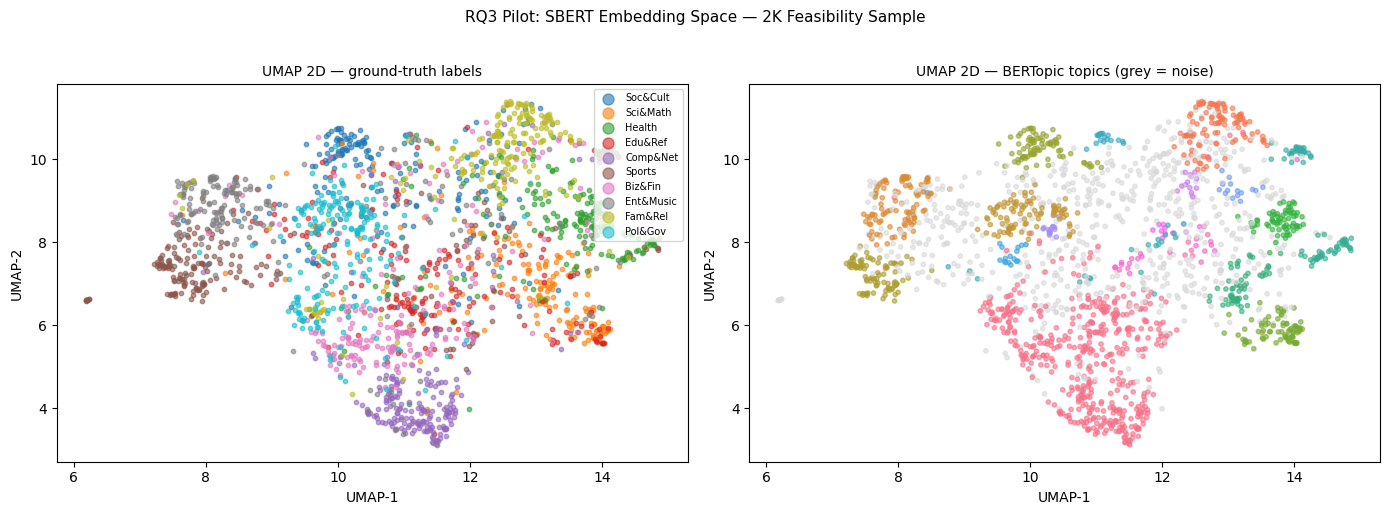

In [25]:
# ─────────────────────────────────────────────────────────────
# 6.3c  UMAP 2D projection — label vs BERTopic topic
# ─────────────────────────────────────────────────────────────
umap_2d = UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
proj_2d = umap_2d.fit_transform(emb_feas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label in range(10):
    m = feas_labels == label
    axes[0].scatter(proj_2d[m,0], proj_2d[m,1],
                    c=[CLASS_COLORS[label]], label=SHORT_NAMES[label], s=10, alpha=0.6)
axes[0].set_title('UMAP 2D — ground-truth labels', fontsize=10)
axes[0].legend(markerscale=2.5, fontsize=7, loc='upper right')
axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')

unique_t = sorted(t for t in set(topics_arr) if t != -1)
t_pal    = sns.color_palette('husl', len(unique_t))
t_cmap   = {t: t_pal[i] for i,t in enumerate(unique_t)}
t_cmap[-1] = (0.85, 0.85, 0.85)
axes[1].scatter(proj_2d[:,0], proj_2d[:,1],
                c=[t_cmap[t] for t in topics_arr], s=10, alpha=0.6)
axes[1].set_title('UMAP 2D — BERTopic topics (grey = noise)', fontsize=10)
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')

fig.suptitle('RQ3 Pilot: SBERT Embedding Space — 2K Feasibility Sample',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# ─────────────────────────────────────────────────────────────
# 6.3d  Top-8 keywords per discovered topic
#
# BERTopic labels topics with c-TF-IDF. We check coherence:
# do keywords form a semantically meaningful cluster?
# ─────────────────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()
print(f'Top-8 keywords per topic ({n_topics} topics found):\n')
for _, row in topic_info.iterrows():
    if row['Topic'] == -1: continue
    kws = [w for w, _ in topic_model.get_topic(row['Topic'])[:8]]
    print(f'  Topic {row["Topic"]:>3} (n={row["Count"]:>4}): {" | ".join(kws)}')

Top-8 keywords per topic (20 topics found):

  Topic   0 (n= 470): to | my | how | in | can | is | the | on
  Topic   1 (n= 106): do | love | me | him | to | he | guy | how
  Topic   2 (n=  96): song | who | the | movie | think | show | of | and
  Topic   3 (n=  94): bush | the | why | of | war | in | was | so
  Topic   4 (n=  90): cup | the | world | football | team | who | game | player
  Topic   5 (n=  84): god | bible | you | the | believe | in | jesus | christians
  Topic   6 (n=  77): math | the | of | calculator | question | figure | is | how
  Topic   7 (n=  68): my | have | what | sore | to | skin | body | get
  Topic   8 (n=  57): water | what | ice | is | does | of | the | iron
  Topic   9 (n=  42): weight | lose | diet | pounds | best | week | for | tried
  Topic  10 (n=  34): help | please | need | me | this | plz | agin | professional
  Topic  11 (n=  19): start | jump | ollie | miles | you | when | how | foot
  Topic  12 (n=  17): did | think | you | true | do | about | 

**RQ3 Pilot Interpretation:** The pilot confirms the full pipeline runs end-to-end in 1.8s for 2K docs (0.9 ms/doc), extrapolating to ~0.7 minutes for the full 50K sample — well within Colab GPU runtime limits. BERTopic found 20 topics with ARI=0.284 and NMI=0.471 against ground-truth labels, meaning the unsupervised structure has real but imperfect alignment with human categories — exactly the non-trivial result that makes RQ3 interesting.

The topic keywords directly validate the EDA-3 findings. The homogeneous categories produced tight, coherent single topics: Topic 4 ("cup", "football", "world", "team", "player") maps cleanly to Sports, and Topic 5 ("god", "bible", "jesus", "christians") maps cleanly to Society & Culture — consistent with their high within-class similarity scores (Sports: 0.0082, Soc&Cult: 0.0063). The diverse categories fragmented as predicted: Health split into at least three topics — Topic 7 (body symptoms: "sore", "skin", "body"), Topic 9 (weight loss: "weight", "lose", "diet", "pounds"), and Topic 14 (sexual health: "sex", "erection", "men") — consistent with Health being the most internally diverse category (0.0046). Science & Math fragmented into Topic 6 (mathematics: "math", "calculator"), Topic 8 (physical science: "water", "ice", "iron"), and Topic 11 (sports science/physics: "jump", "ollie", "miles").

Critically, several topics cross category boundaries exactly where EDA-4 identified the highest confusion: Topic 18 ("essay", "paper", "help", "research") pulls from both Education & Reference and Science & Math — the same Edu&Ref → Sci&Math pair with confusion rate 0.136. Topic 0 (the large noise-adjacent generic topic with 470 docs) absorbs generic posts from multiple categories, which explains the 32.4% noise rate and aligns with EDA-1's finding that generic help-seeking tokens dominate across all categories. The UMAP left panel confirms that no category forms a perfectly isolated cluster — all show boundary overlap with neighbours, with Sports and Computers & Internet being the most spatially coherent, again matching their high per-class F1 in EDA-4 (0.824 and 0.803 respectively). The full 50K run will determine whether the cross-category topic structure (Topic 18, Topic 0) is robust at scale or an artefact of the small 2K sample.

---
# Section 7 — Sanity Tests

Each test validates a non-trivial assumption. Each is motivated by a specific failure mode that would silently corrupt results.

In [27]:
# ─────────────────────────────────────────────────────────────
# Test 1: Pilot training set is stratified
#
# Failure mode: over-represented class inflates macro-F1,
# giving a misleadingly optimistic baseline.
# ─────────────────────────────────────────────────────────────
def test_stratified_pilot(df, target=5_000, tol=0.05):
    counts   = df['class_index'].value_counts()
    expected = min(target, counts.min())
    for label, count in counts.items():
        assert abs(count - expected) / expected <= tol, (
            f'Class {label}: {count} samples, expected ~{expected}'
        )
    print(f'PASS test_stratified_pilot — all 10 classes within {tol*100:.0f}% of {expected}')

test_stratified_pilot(pilot_train)

PASS test_stratified_pilot — all 10 classes within 5% of 5000


In [28]:
# ─────────────────────────────────────────────────────────────
# Test 2: Text configurations differ meaningfully in length
#
# Failure mode: if configs are the same length, concatenation
# added no new text and RQ2 is trivially uninteresting.
# ─────────────────────────────────────────────────────────────
def test_config_lengths_differ(df, threshold=1.05):
    la = df['text_A'].str.split().str.len().mean()
    lb = df['text_B'].str.split().str.len().mean()
    lc = df['text_C'].str.split().str.len().mean()
    assert lb >= la * threshold, f'Config B ({lb:.1f}w) not > Config A ({la:.1f}w)'
    assert lc >= lb * threshold, f'Config C ({lc:.1f}w) not > Config B ({lb:.1f}w)'
    print(f'PASS test_config_lengths_differ — A={la:.0f}w, B={lb:.0f}w, C={lc:.0f}w')

test_config_lengths_differ(train_df)

PASS test_config_lengths_differ — A=10w, B=50w, C=117w


In [29]:
# ─────────────────────────────────────────────────────────────
# Test 3: TF-IDF vocabulary is large enough to be informative
#
# Failure mode: <1K features → classifier near-random (F1 ≈ 0.1)
# → would signal catastrophic over-filtering.
# ─────────────────────────────────────────────────────────────
def test_tfidf_vocab_size(pipeline, min_vocab=10_000):
    vocab = len(pipeline.named_steps['tfidf'].vocabulary_)
    assert vocab >= min_vocab, f'Vocab {vocab:,} < {min_vocab:,}'
    print(f'PASS test_tfidf_vocab_size — vocabulary = {vocab:,} features')

test_tfidf_vocab_size(rq1_results[best_name]['pipe'])

PASS test_tfidf_vocab_size — vocabulary = 50,000 features


In [30]:
# ─────────────────────────────────────────────────────────────
# Test 4: SBERT embeddings have correct shape and no NaN/Inf
#
# Failure mode: shape mismatch or NaN silently corrupts UMAP
# and HDBSCAN, producing meaningless clustering without error.
# ─────────────────────────────────────────────────────────────
def test_embedding_quality(embeddings, expected_n, expected_dim=384):
    assert embeddings.shape == (expected_n, expected_dim), (
        f'Expected ({expected_n},{expected_dim}), got {embeddings.shape}'
    )
    assert not np.isnan(embeddings).any(), 'NaN in embeddings'
    assert not np.isinf(embeddings).any(), 'Inf in embeddings'
    print(f'PASS test_embedding_quality — shape={embeddings.shape}, no NaN/Inf')

test_embedding_quality(emb_feas, len(feas_docs))

PASS test_embedding_quality — shape=(2000, 384), no NaN/Inf


In [31]:
# ─────────────────────────────────────────────────────────────
# Test 5: McNemar contingency table is internally consistent
#
# Failure mode 1: table doesn't sum to test set size
#   → predictions from different sample sizes → invalid statistic
# Failure mode 2: both discordant cells = 0
#   → classifiers identical → test undefined
# ─────────────────────────────────────────────────────────────
def test_mcnemar_table(n00, n01, n10, n11, n_expected):
    total = n00 + n01 + n10 + n11
    assert total == n_expected, f'Table sums to {total:,}, expected {n_expected:,}'
    assert (n01 + n10) > 0, 'Both discordant cells zero — test undefined'
    print(f'PASS test_mcnemar_table — total={total:,}, n01={n01:,}, n10={n10:,}')

test_mcnemar_table(n00, n01, n10, n11, len(y_test))

print('\n✓ All 5 sanity tests passed.')

PASS test_mcnemar_table — total=32,265, n01=5,835, n10=2,502

✓ All 5 sanity tests passed.


## Test Coverage Summary

| Test | Property validated | Failure mode prevented |
|------|-------------------|------------------------|
| `test_stratified_pilot` | All 10 classes within 5% of 5K target | Macro-F1 inflated by over-represented majority class |
| `test_config_lengths_differ` | Configs B and C meaningfully longer than A | RQ2 ablation is trivially uninteresting |
| `test_tfidf_vocab_size` | Vocabulary ≥ 10K features | Over-filtering collapses classifier to near-random |
| `test_embedding_quality` | SBERT shape (N,384), no NaN/Inf | Silent corruption of UMAP/HDBSCAN |
| `test_mcnemar_table` | Table sums to test set size; discordant cells > 0 | Invalid McNemar statistic |

---
# Summary

| # | Research Question | EDA That Motivated It | Technique Type | Algorithms | Primary Metric |
|---|---|---|---|---|---|
| RQ1 | How well do TF-IDF classifiers perform at scale, and which pairs are most confused? | EDA-1 (overlap), EDA-4 (probe) | Course — Wk7 + Wk5 | TF-IDF, NB, LogReg, LinearSVC | Macro-F1, confusion matrix |
| RQ2 | Does adding content/answer improve accuracy, and is the benefit uniform per category? | EDA-2 (field signal) | Course — Wk7 + Wk5 | TF-IDF, LogReg, McNemar | Macro-F1 delta, p-value |
| RQ3 | Does BERTopic latent structure align with or cut across human labels? | EDA-3 (diversity), EDA-4 (confusion) | External (CP1 techniques) | SBERT, UMAP, HDBSCAN, BERTopic | ARI, NMI, coherence |

1. **EDA** discovered that vocabulary overlap is near-universal but driven by generic tokens (EDA-1), that field signal varies structurally by category with Business & Finance and Sports missing content for over half their posts (EDA-2), that Health and Science & Math are the most lexically diverse while Computers & Internet and Family & Relationships are the tightest (EDA-3), and that probe macro-F1 is 0.687 with Education & Reference (0.506) and Society & Culture (0.564) as the hardest categories and Edu&Ref ↔ Sci&Math as the dominant confusion pair (EDA-4).
2. **RQ1 pilot** achieves macro-F1 of 0.711 at 50K with Naive Bayes leading, replicating the EDA-4 per-class pattern — Computers & Internet (0.850) easiest, Education & Reference (0.531) hardest.
3. **RQ2 pilot** confirms Config C beats Config A by a statistically significant margin (McNemar p=1.47e-291), with per-class gains matching EDA-2's empty-content rate predictions — Health gains +0.13, Business & Finance gains only +0.05.
4. **RQ3 pilot** encodes 2K docs in 1.8s (~0.7 min extrapolated to 50K), finds 20 topics (ARI=0.284, NMI=0.471), with Health fragmenting into body symptoms, weight loss, and sexual health sub-topics exactly as EDA-3 predicted, and cross-category Topic 18 matching the Edu&Ref ↔ Sci&Math confusion pair from EDA-4.

---
# Resources

1. **Collaborators:** None

2. **Web Sources**
   - Yahoo Answers Dataset — https://www.kaggle.com/datasets/yacharki/yahoo-answers-10-categories-for-nlp-csv
   - BERTopic Documentation — https://maartengr.github.io/BERTopic/
   - scikit-learn Documentation — https://scikit-learn.org/stable/
   - Hugging Face `all-MiniLM-L6-v2` — https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

3. **AI Tools:** Claude (Anthropic) for structure guidance and documentation review

4. **Citations**
   - Devlin et al., *BERT*, NAACL 2019 — https://arxiv.org/abs/1810.04805
   - Reimers & Gurevych, *Sentence-BERT*, EMNLP 2019 — https://arxiv.org/abs/1908.10084
   - Grootendorst, *BERTopic*, arXiv 2022 — https://arxiv.org/abs/2203.05794
   - McInnes et al., *UMAP*, JOSS 2018 — https://arxiv.org/abs/1802.03426
   - Howard & Ruder, *ULMFiT*, ACL 2018 — https://arxiv.org/abs/1801.06146